# MMC Chatbot — Clustering Benchmark

**One notebook, every viable clustering approach.** We cluster the chatbot's
messages (and users) with KMeans, GaussianMixture, HDBSCAN, Agglomerative,
Spectral, BERTopic and LDA, over both **semantic** (multilingual e5-large
embeddings) and **lexical** (TF-IDF) representations. For each method we show a
2-D cluster map, representative example messages, three suggested cluster names
(bot-`Chat_summary` consensus · top TF-IDF terms · optional LLM), and a rich set
of evaluation metrics — so we can decide which approach best fits this corpus.

*Exploratory / benchmark notebook. It does not replace `analysis_responses.ipynb`;
it is the sandbox that justifies the clustering choices made there.*

## 0. Setup — data, embeddings, representations *(computed once, reused everywhere)*

In [1]:
import sys, os, time, warnings, itertools
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch

import palette as P
from palette import CAT, BLUE_SEQ, cat_colors, seq_colors, NEGRO
import mmc_data, mmc_text
from mmc_text import SPANISH_STOPWORDS

RNG = 42
np.random.seed(RNG)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NOISE_COLOR = "#e0dedb"     # light grey for HDBSCAN/DBSCAN noise points

# The 7 official MMC topic categories (bot Chat_summary vocabulary).
MMC_CATS = {"humanitarian assistance", "legal documentation", "protection",
            "employment", "organization search", "journey information", "services"}

print("device:", DEVICE, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu128


In [2]:
# --- message level -------------------------------------------------------
df   = mmc_data.load_responses()
msgs = mmc_data.load_messages(df).reset_index(drop=True)

# Normalize the bot's own Chat_summary label -> pseudo ground-truth `cs`.
# Dedupe on phone via .map (NOT merge): duplicate phones would explode rows.
import re
_CANON = {"legaldocumentation": "legal documentation",
          "humanitarianassistance": "humanitarian assistance",
          "journeyinformation": "journey information",
          "organizationsearch": "organization search"}
def norm_cs(v):
    if not isinstance(v, str):
        return None
    s = re.sub(r"\s+", " ", v.lower().lstrip("#").strip().replace("_", " "))
    if "," in s or "hashtag" in s or "use exactly" in s:
        return None
    return s if s in MMC_CATS else _CANON.get(s.replace(" ", ""))

cs_map = (df.assign(cs=df["Chat_summary"].map(norm_cs)).dropna(subset=["cs"])
            .drop_duplicates("phone").set_index("phone")["cs"])
msgs["cs"] = msgs["phone"].map(cs_map)

# --- user level (aggregate turns per phone) ------------------------------
_carry = {c: (c, "first") for c in
          ["city_canon", "Gender", "Age Ranges", "Nationality", "n_msgs_user"]}
users = (msgs.groupby("phone")
              .agg(text=("message", lambda s: "  ".join(s)), **_carry)
              .reset_index())
users["cs"] = users["phone"].map(cs_map)

print(f"messages: {len(msgs)}  |  users: {len(users)}")
print(f"labelled by bot (cs not null): msgs {msgs['cs'].notna().mean()*100:.0f}%  "
      f"users {users['cs'].notna().mean()*100:.0f}%")
msgs[["message", "cs"]].head(4)

messages: 2993  |  users: 800
labelled by bot (cs not null): msgs 99%  users 100%


,message,cs
0,Soy mujer migrantes residenciada en Medellín y...,humanitarian assistance
1,Hola,services
2,Quiero informacion de loa servicios,services
3,Solo me gustaría saber cómo hago para sacar el...,legal documentation


In [3]:
# --- semantic embeddings (e5-large, fp16 GPU, computed ONCE) -------------
from sentence_transformers import SentenceTransformer

def e5_embed(texts):
    m = SentenceTransformer("intfloat/multilingual-e5-large", device=DEVICE)
    if DEVICE == "cuda":
        m = m.half()
    v = m.encode(["query: " + t for t in texts], batch_size=32,
                 normalize_embeddings=True, show_progress_bar=False)
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return np.asarray(v, dtype="float32")

t = time.time()
emb   = e5_embed(msgs["message"].tolist())
emb_u = e5_embed(users["text"].str.slice(0, 1200).tolist())   # cap very long users
print(f"embedded  msgs {emb.shape}  users {emb_u.shape}  in {time.time()-t:.1f}s")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embedded  msgs (2993, 1024)  users (800, 1024)  in 26.1s


In [4]:
# --- reductions + lexical matrices (computed ONCE) ----------------------
from umap import UMAP
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

def umap2(x):  return UMAP(n_neighbors=15, n_components=2, min_dist=0.05,
                           metric="cosine", random_state=RNG).fit_transform(x)
def umap15(x): return UMAP(n_neighbors=15, n_components=15, min_dist=0.0,
                           metric="cosine", random_state=RNG).fit_transform(x)

t = time.time()
red2,  red2_u  = umap2(emb),  umap2(emb_u)     # 2-D for plotting
red15, red15_u = umap15(emb), umap15(emb_u)    # 15-D clustering space
pca50   = PCA(n_components=50, random_state=RNG).fit(emb);   Xpca   = pca50.transform(emb)
pca50_u = PCA(n_components=50, random_state=RNG).fit(emb_u); Xpca_u = pca50_u.transform(emb_u)

_vec = TfidfVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2),
                       min_df=3, max_features=8000)
tfidf   = _vec.fit_transform(msgs["message"]);   TFVOCAB   = np.array(_vec.get_feature_names_out())
_vec_u = TfidfVectorizer(stop_words=SPANISH_STOPWORDS, ngram_range=(1, 2),
                         min_df=3, max_features=8000)
tfidf_u = _vec_u.fit_transform(users["text"]);   TFVOCAB_U = np.array(_vec_u.get_feature_names_out())

_svd   = TruncatedSVD(n_components=100, random_state=RNG); tfsvd   = _svd.fit_transform(tfidf)
_svd_u = TruncatedSVD(n_components=100, random_state=RNG); tfsvd_u = _svd_u.fit_transform(tfidf_u)
print(f"reductions built in {time.time()-t:.1f}s  |  tfidf msgs {tfidf.shape}  users {tfidf_u.shape}")

LEADER, LEADER_U = [], []   # leaderboard rows filled in §2 / §7
LABELS,  LABELS_U = {}, {}   # {method_name: labels array}

reductions built in 63.9s  |  tfidf msgs (2993, 1476)  users (800, 1351)


## 1. Representations — semantic vs lexical

**What this shows.** We cluster in two different spaces. The **semantic** space
(e5-large embeddings) places messages by meaning, so paraphrases land together.
The **lexical** space (TF-IDF) places them by shared words, so it is sharper on
exact terminology but blind to synonyms. The bars below show how much variance a
linear projection keeps in each space, and the neighbour check contrasts what
"nearest" means in each.

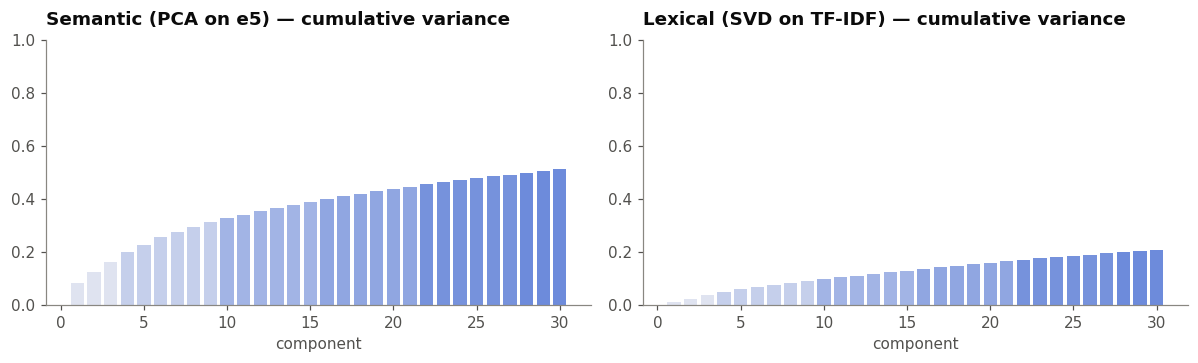

QUERY: Estoy en Medellín y si necesito el enlace

semantic neighbours:
  · Estoy en Medellín
  · Si necesito saber en Medellín si de puedo acudir y q necesito... Ambos somos ven
  · Me encuentro en medellín

lexical neighbours:
  · Estoy en Medellín
  · Estoy en Medellín Belén
  · Estoy en medellín


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(range(1, 31), np.cumsum(pca50.explained_variance_ratio_)[:30],
          color=seq_colors(30))
ax[0].set_title("Semantic (PCA on e5) — cumulative variance"); ax[0].set_xlabel("component")
ax[1].bar(range(1, 31), np.cumsum(_svd.explained_variance_ratio_)[:30],
          color=seq_colors(30))
ax[1].set_title("Lexical (SVD on TF-IDF) — cumulative variance"); ax[1].set_xlabel("component")
for a in ax: a.set_ylim(0, 1)
plt.tight_layout(); plt.show()

# nearest-neighbour sanity check for one message in each space
from sklearn.metrics.pairwise import cosine_similarity
i = int(msgs["message"].str.len().sort_values().index[len(msgs)//2])
def nn(matrix, i, k=3):
    sims = cosine_similarity(matrix[i:i+1], matrix).ravel(); order = sims.argsort()[::-1]
    return [j for j in order if j != i][:k]
print("QUERY:", msgs.loc[i, "message"][:90])
print("\nsemantic neighbours:")
for j in nn(emb, i): print("  ·", msgs.loc[j, "message"][:80])
print("\nlexical neighbours:")
for j in nn(tfidf.toarray(), i): print("  ·", msgs.loc[j, "message"][:80])